## **PHASE 1**

### Step 1: Import Heart Disease Health Dataset & Pre-process

In [ ]:
import kagglehub

# Download the Heart Disease Health Indicators Dataset
heart_disease_path = kagglehub.dataset_download("alexteboul/heart-disease-health-indicators-dataset")

print("Path to Heart Disease dataset files:", heart_disease_path)

Using Colab cache for faster access to the 'heart-disease-health-indicators-dataset' dataset.
Path to Heart Disease dataset files: /kaggle/input/heart-disease-health-indicators-dataset


In [ ]:
import pandas as pd
import os

# Load the Heart Disease Health Indicators dataset
heart_disease_df = pd.read_csv(os.path.join(heart_disease_path, 'heart_disease_health_indicators_BRFSS2015.csv'))

heart_disease_df.head()

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


### Step 2. Cleaning the Heart Disease dataframe

In [ ]:
initial_rows = heart_disease_df.shape[0]

# Remove duplicates
heart_disease_df = heart_disease_df.drop_duplicates()
duplicates_removed = initial_rows - heart_disease_df.shape[0]
print(f"Removed {duplicates_removed} duplicate rows. Remaining rows: {heart_disease_df.shape[0]}")

Removed 23899 duplicate rows. Remaining rows: 229781


In [ ]:
# Convert common categorical columns to int (Age, HighBP, etc.)
cols_to_fix = ['Age', 'Sex', 'HighBP', 'HighChol', 'HeartDiseaseorAttack']
heart_disease_df[cols_to_fix] = heart_disease_df[cols_to_fix].astype(int)

print("Data types after specific column conversion:")
print(heart_disease_df[cols_to_fix].dtypes)

Data types after specific column conversion:
Age                     int64
Sex                     int64
HighBP                  int64
HighChol                int64
HeartDiseaseorAttack    int64
dtype: object


### Step 3. Create the model

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report

# Create model to calculate the probability score from all the biological markers in the heart_disease_df dataset
# Define the factors requested
features = ['Age', 'Sex', 'HighBP', 'HighChol', 'Diabetes', 'Smoker', 'HvyAlcoholConsump']
target = 'HeartDiseaseorAttack'

X = heart_disease_df[features]
y = heart_disease_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train the Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Evaluate the model on the test set
y_pred_prob_test = model.predict_proba(X_test)[:, 1]
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_prob_test):.4f}")
print(classification_report(y_test, model.predict(X_test)))

# Calculate probability scores and add as new column
heart_disease_df['heart_disease_prob'] = model.predict_proba(X)[:, 1]

# Display coefficients to understand the 'weight' of each factor
importance = pd.DataFrame({'Feature': features, 'Weight (Coefficient)': model.coef_[0]})
print("\nModel Feature Weights:")
display(importance.sort_values(by='Weight (Coefficient)', ascending=False))

# Make all weights positive
importance['Weight (Coefficient)'] = importance['Weight (Coefficient)'].abs()
print("\nModel Feature Absolute Weights:")
display(importance.sort_values(by='Weight (Coefficient)', ascending=False))

print("\nSample probabilities added to heart_disease_df:")
display(heart_disease_df[['Age', 'Sex', 'HeartDiseaseorAttack', 'heart_disease_prob']].head())

ROC-AUC Score: 0.7959
              precision    recall  f1-score   support

           0       0.90      1.00      0.95     41214
           1       0.44      0.02      0.04      4743

    accuracy                           0.90     45957
   macro avg       0.67      0.51      0.49     45957
weighted avg       0.85      0.90      0.85     45957


Model Feature Weights:


,Feature,Weight (Coefficient)
2,HighBP,0.744472
3,HighChol,0.680765
1,Sex,0.594733
5,Smoker,0.507563
4,Diabetes,0.308163
0,Age,0.244628
6,HvyAlcoholConsump,-0.479291



Model Feature Absolute Weights:


,Feature,Weight (Coefficient)
2,HighBP,0.744472
3,HighChol,0.680765
1,Sex,0.594733
5,Smoker,0.507563
6,HvyAlcoholConsump,0.479291
4,Diabetes,0.308163
0,Age,0.244628



Sample probabilities added to heart_disease_df:


,Age,Sex,HeartDiseaseorAttack,heart_disease_prob
0,9,0,0,0.143575
1,7,0,0,0.024118
2,9,0,0,0.091665
3,11,0,0,0.076918
4,11,0,0,0.141339


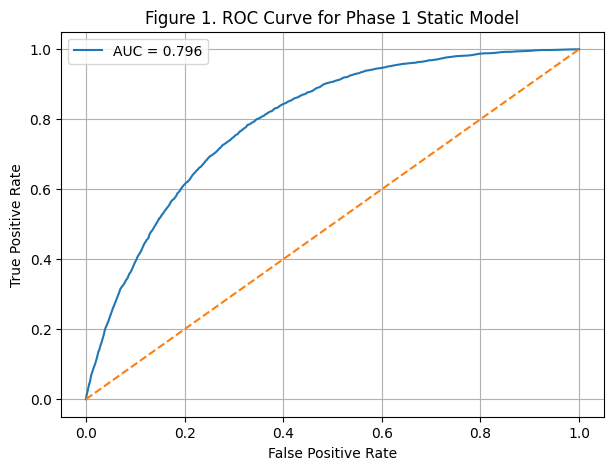

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob_test)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Figure 1. ROC Curve for Phase 1 Static Model")
plt.legend()
plt.grid()
plt.show()

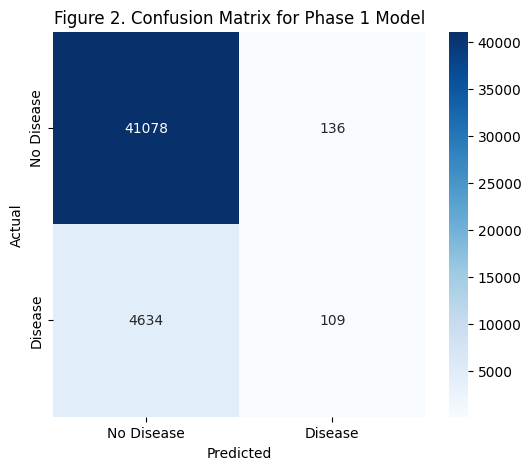

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_pred_phase1 = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_phase1)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Disease", "Disease"],
            yticklabels=["No Disease", "Disease"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Figure 2. Confusion Matrix for Phase 1 Model")
plt.show()

### Current Model Performance:

- ROC-AUC Score: 0.7959, indicating a strong ability to distinguish between high-risk and low-risk individuals.

- Strengths: The model correctly identifies the majority of healthy cases (90% precision for the negative class).

- Weaknesses: It currently struggles with recall for the positive class as static survey data often lacks the real-time physiological red flags that occur shortly before a cardiac event.

### Why Integrate Multilevel Monitoring of Activity and Sleep in Healthy People Dataset
While static clinical datasets (Phase 1) successfully capture long-term, baseline risk factors (e.g., BMI, smoking history, chronic conditions), they inherently lack the resolution to detect acute physiological deterioration. Static surveys only provide a point-in-time snapshot.

By using the MMASH dynamic dataset, we move from static profiling to continuous physiological monitoring. Time-series data like beat-to-beat intervals (Heart Rate Variability), continuous actigraphy, and sleep fragmentation metrics allows the model to capture the link between cardiovascular strain, physical exertion, and physiological recovery. This continuous data loop provides more features for identifying cardiovascular diseases.

### Expected Impact
* Recall For Positive Class: By capturing real-time physiological anomalies (such as sudden drops in HRV or severe sleep fragmentation), the model can flag individuals whose static profiles might appear healthy.
* Better Feature Interactions: We expect to see strong predictive interactions between disrupted sleep fragmentation and elevated daytime resting heart rates, driving higher overall model accuracy and F1-scores compared to the Phase 1 baseline.

## **PHASE 2**

### Step 1: Setting up the data (by aggregrating the data directories)

In [ ]:
# Download the dataset
path = kagglehub.dataset_download("dijanajanjetovic/mmash-dataset")
print(f"Base path: {path}")

rr_list = []
actigraph_list = []
sleep_list = []

# Walk through every single directory and sub-directory
for root, dirs, files in os.walk(path):

    if 'RR.csv' in files or 'sleep.csv' in files:
        # Grab the folder name
        user_id = os.path.basename(root)

        # Load RR.csv
        if 'RR.csv' in files:
            df_rr = pd.read_csv(os.path.join(root, 'RR.csv'))
            df_rr['user_id'] = user_id
            rr_list.append(df_rr)

        # Load Actigraph.csv
        if 'Actigraph.csv' in files:
            df_act = pd.read_csv(os.path.join(root, 'Actigraph.csv'))
            df_act['user_id'] = user_id
            actigraph_list.append(df_act)

        # Load sleep.csv
        if 'sleep.csv' in files:
            df_sleep = pd.read_csv(os.path.join(root, 'sleep.csv'))
            df_sleep['user_id'] = user_id
            sleep_list.append(df_sleep)

# Concatenate
if rr_list:
    master_rr_df = pd.concat(rr_list, ignore_index=True)
    print(f"Master RR Shape: {master_rr_df.shape}")
else:
    print("Warning: No RR data found.")

if actigraph_list:
    master_actigraph_df = pd.concat(actigraph_list, ignore_index=True)
    print(f"Master Actigraph Shape: {master_actigraph_df.shape}")
else:
    print("Warning: No Actigraph data found.")

if sleep_list:
    master_sleep_df = pd.concat(sleep_list, ignore_index=True)
    print(f"Master Sleep Shape: {master_sleep_df.shape}")
else:
    print("Warning: No Sleep data found.")

# Verify the output
if rr_list:
    display(master_rr_df.head())

Using Colab cache for faster access to the 'mmash-dataset' dataset.
Base path: /kaggle/input/mmash-dataset
Master RR Shape: (1749295, 5)
Master Actigraph Shape: (1462678, 14)
Master Sleep Shape: (22, 18)


/tmp/ipykernel_52811/1121556346.py:48: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  master_sleep_df = pd.concat(sleep_list, ignore_index=True)


,Unnamed: 0,ibi_s,day,time,user_id
0,1,18.514,1,09:05:24,user_10
1,2,0.268,1,09:05:25,user_10
2,3,0.645,1,09:05:42,user_10
3,4,0.681,1,09:05:43,user_10
4,5,0.771,1,09:05:43,user_10


### Step 2: Feature Engineering

- Transforming raw signal data into meaningful physiological insights. We migrate from static averages to a Rolling Time-Series approach, chunking data into 543 hourly windows.
- For each window, we calculate RMSSD (Heart Rate Variability), average cardiovascular strain, and incorporate "Hour of Day" to account for circadian rhythm influences on cardiac performance.

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Create Hourly Windows for RR (HRV) Data
# Extract the hour and create a unique window ID
master_rr_df['hour'] = master_rr_df['time'].astype(str).str[:2]
master_rr_df['window'] = 'D' + master_rr_df['day'].astype(str) + '_H' + master_rr_df['hour']

master_rr_df = master_rr_df.sort_values(by=['user_id', 'day', 'time'])
master_rr_df['ibi_diff'] = master_rr_df.groupby(['user_id', 'window'])['ibi_s'].diff()

hrv_hourly = master_rr_df.groupby(['user_id', 'window'])['ibi_diff'].apply(
    lambda x: np.sqrt(np.mean(x**2))
).reset_index(name='RMSSD')

# Create Hourly Windows for Actigraph (HR & Movement) Data
master_actigraph_df['hour'] = master_actigraph_df['time'].astype(str).str[:2]
master_actigraph_df['window'] = 'D' + master_actigraph_df['day'].astype(str) + '_H' + master_actigraph_df['hour']

act_hourly = master_actigraph_df.groupby(['user_id', 'window']).agg(
    avg_hr=('HR', 'mean'),
    avg_movement=('Vector Magnitude', 'mean'),
    hour_of_day=('hour', 'first')
).reset_index()

act_hourly['cardio_strain'] = act_hourly['avg_hr'] / (act_hourly['avg_movement'] + 1)
act_hourly['hour_of_day'] = act_hourly['hour_of_day'].astype(int)

### Step 3: Multi-Source Data Fusion & Feature Scaling


In [ ]:
# Synchronizing dynamic time-series windows with static data (Age, Weight, Gender).
user_info_list = []
for root, dirs, files in os.walk(path):
    if 'user_info.csv' in files:
        user_id = os.path.basename(root)
        df_user_info = pd.read_csv(os.path.join(root, 'user_info.csv'))
        df_user_info['user_id'] = user_id
        user_info_list.append(df_user_info)

if user_info_list:
    user_info_df = pd.concat(user_info_list, ignore_index=True)
    print(f"Master User Info Shape: {user_info_df.shape}")
else:
    print("Warning: No user_info data found.")

# Merge Windows & Attach Static Data
# Merge HRV and Actigraph on the specific hour
hourly_dynamic_df = hrv_hourly.merge(act_hourly, on=['user_id', 'window'], how='inner')
hourly_dynamic_df.dropna(subset=['RMSSD'], inplace=True) # Drop hours where HRV math failed
sleep_features = master_sleep_df.groupby('user_id')['Sleep Fragmentation Index'].mean().reset_index()
hourly_dynamic_df = hourly_dynamic_df.merge(sleep_features, on='user_id', how='left')

# Merge the static body metrics
final_ts_df = hourly_dynamic_df.merge(
    user_info_df[['user_id', 'Weight', 'Age']],
    on='user_id',
    how='left'
)

# Imputate and scale data
for col in ['Sleep Fragmentation Index', 'Weight', 'Age']:
    final_ts_df[col] = final_ts_df[col].fillna(final_ts_df[col].median())

features_to_scale = ['RMSSD', 'cardio_strain', 'avg_movement', 'Sleep Fragmentation Index', 'Weight', 'Age']
scaled_cols = [f"{col}_scaled" for col in features_to_scale]

scaler = StandardScaler()
final_ts_df[scaled_cols] = scaler.fit_transform(final_ts_df[features_to_scale])

print(f"Expanded from 22 rows to {final_ts_df.shape[0]} hourly windows.")
display(final_ts_df)

Master User Info Shape: (22, 6)
Expanded from 22 rows to 543 hourly windows.


,user_id,window,RMSSD,avg_hr,avg_movement,hour_of_day,cardio_strain,Sleep Fragmentation Index,Weight,Age,RMSSD_scaled,cardio_strain_scaled,avg_movement_scaled,Sleep Fragmentation Index_scaled,Weight_scaled,Age_scaled
0,user_1,D1_H10,0.666001,92.321171,70.919211,10,1.283679,14.0055,65,29,2.072449,-0.477178,1.208029,-0.947301,-0.795426,0.425666
1,user_1,D1_H11,0.050210,81.904244,40.840319,11,1.957543,14.0055,65,29,-0.426682,-0.435213,0.197578,-0.947301,-0.795426,0.425666
2,user_1,D1_H12,0.053229,74.565870,49.656853,12,1.471980,14.0055,65,29,-0.414431,-0.465452,0.493755,-0.947301,-0.795426,0.425666
3,user_1,D1_H13,0.062313,90.663089,76.528906,13,1.169410,14.0055,65,29,-0.377562,-0.484294,1.396477,-0.947301,-0.795426,0.425666
4,user_1,D1_H14,0.030015,102.564637,62.765376,14,1.608469,14.0055,65,29,-0.508643,-0.456952,0.934114,-0.947301,-0.795426,0.425666
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
538,user_9,D1_H19,0.034751,127.183849,214.858117,19,0.589201,8.0950,70,20,-0.489420,-0.520427,6.043420,-1.488923,-0.394910,-0.861605
539,user_9,D1_H20,0.025983,156.164501,226.479713,20,0.686499,8.0950,70,20,-0.525004,-0.514368,6.433829,-1.488923,-0.394910,-0.861605
540,user_9,D1_H21,0.538775,100.575544,33.331056,21,2.929579,8.0950,70,20,1.556111,-0.374679,-0.054683,-1.488923,-0.394910,-0.861605
541,user_9,D1_H22,0.028244,81.663216,20.261235,22,3.840944,8.0950,70,20,-0.515831,-0.317924,-0.493743,-1.488923,-0.394910,-0.861605


### Step 4: Advanced Modeling with XGBoost Gradient Boosting

In [ ]:
import xgboost as xgb

# Define the Proxy Target (High Strain = 1)
# We identify specific HOURS where the user is under severe physiological load
final_ts_df['High_Risk_Flag'] = ((final_ts_df['RMSSD_scaled'] < 0) &
                                 (final_ts_df['cardio_strain_scaled'] > 0)).astype(int)

features = ['hour_of_day', 'avg_movement_scaled', 'Sleep Fragmentation Index_scaled', 'Weight_scaled', 'Age_scaled']
X = final_ts_df[features]
y = final_ts_df['High_Risk_Flag']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

### Step 5: Performance Validation

Phase 2 Time-Series Model (XGBoost)
ROC-AUC Score: 0.9838

              precision    recall  f1-score   support

           0       0.98      0.97      0.97        87
           1       0.87      0.91      0.89        22

    accuracy                           0.95       109
   macro avg       0.92      0.94      0.93       109
weighted avg       0.96      0.95      0.95       109



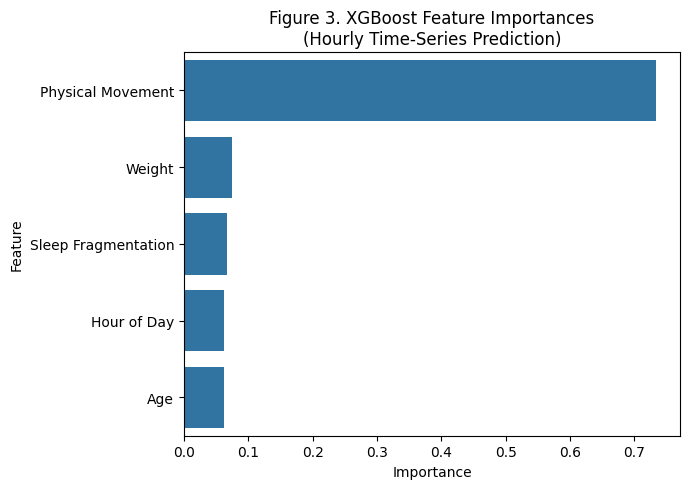

In [ ]:
# Evaluate the Model
y_pred = xgb_model.predict(X_test)
y_pred_prob = xgb_model.predict_proba(X_test)[:, 1]

print("Phase 2 Time-Series Model (XGBoost)")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_prob):.4f}\n")
print(classification_report(y_test, y_pred, zero_division=0))

# Generate the Feature Importance Plot
importances = pd.DataFrame({
    'Feature': ['Hour of Day', 'Physical Movement', 'Sleep Fragmentation', 'Weight', 'Age'],
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(7, 5))
sns.barplot(data=importances, x='Importance', y='Feature')
plt.title("Figure 3. XGBoost Feature Importances\n(Hourly Time-Series Prediction)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

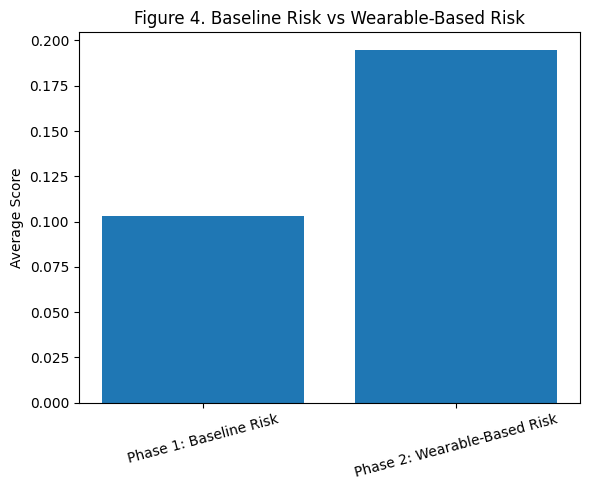

                          Model  Average Risk Score
0        Phase 1: Baseline Risk            0.103231
1  Phase 2: Wearable-Based Risk            0.194769


In [ ]:
# Phase 1 vs Phase 2 risk comparison
final_ts_df['adjusted_risk_score'] = xgb_model.predict_proba(
    final_ts_df[features]
)[:, 1]

phase1_avg_risk = heart_disease_df['heart_disease_prob'].mean()
phase2_avg_risk = final_ts_df['adjusted_risk_score'].mean()

risk_comparison = pd.DataFrame({
    'Model': ['Phase 1: Baseline Risk', 'Phase 2: Wearable-Based Risk'],
    'Average Risk Score': [phase1_avg_risk, phase2_avg_risk]
})

plt.figure(figsize=(6,5))
plt.bar(risk_comparison['Model'], risk_comparison['Average Risk Score'])
plt.ylabel('Average Score')
plt.title('Figure 4. Baseline Risk vs Wearable-Based Risk')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print(risk_comparison)

# Conclusion
Phase 1 gives a lower average risk probability because it’s based on long-term factors like age and health conditions. Phase 2 is higher because it captures real-time stress from things like movement and heart rate variability. This shows that wearable data can pick up short-term spikes in risk that the baseline model misses.